<a href="https://colab.research.google.com/github/chyrchxela/ML_HW/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3

## Цель работы

Цель данной лабораторной работы — обучить более сложную модель машинного обучения для предсказания успешности компьютерной игры, подобрать для неё гиперпараметры с помощью кросс-валидации и провести интерпретацию полученных результатов.

## Описание данных

В работе используется датасет со сведениями об играх в Steam. В нём содержатся числовые и категориальные признаки, характеризующие популярность, цену, отзывы и другие свойства игр.

Целевая переменная `is_hit` формируется на основе признаков `owners`, `average_forever` и `median_forever`. Для этого вычисляется интегральный показатель популярности `popularity_score`, после чего объект относится к классу 1, если его значение попадает в верхние 20% распределения.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_auc_score,
    precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
%matplotlib inline


## Подготовка данных

На данном этапе выполняется загрузка датасета, приведение отдельных признаков к числовому типу и построение целевой переменной `is_hit`. Такой подход сохраняет логику, использованную в предыдущей лабораторной работе, и обеспечивает сопоставимость результатов между моделями.

Так как задача является задачей бинарной классификации, далее используется разбиение выборки на обучающую и тестовую части со стратификацией по целевому признаку. Это позволяет сохранить исходное соотношение классов в обеих выборках и сделать итоговую оценку более корректной.


In [33]:
df = pd.read_csv("/content/steam_games_dataset 2.csv")

for col in ["owners", "average_forever", "median_forever"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

target_cols = [col for col in ["owners", "average_forever", "median_forever"] if col in df.columns]

df["popularity_score"] = df[target_cols].max(axis=1)
threshold = df["popularity_score"].quantile(0.8)
df["is_hit"] = (df["popularity_score"] >= threshold).astype(int)

print(df.shape)
print(df["is_hit"].value_counts(normalize=True))


(10000, 19)
is_hit
0    0.7997
1    0.2003
Name: proportion, dtype: float64


## Разделение признаков и выборок

После построения целевой переменной из набора данных удаляются служебные столбцы, которые напрямую участвуют в её формировании. Это необходимо для предотвращения утечки целевой переменной и для получения более честной оценки качества модели.

Затем признаки разделяются на числовые и категориальные. Такое разделение нужно для того, чтобы в пайплайне применить к ним разные шаги предобработки: для числовых признаков — заполнение пропусков и масштабирование, для категориальных — заполнение пропусков и one-hot encoding.


In [34]:
target_col = "is_hit"

drop_cols = [target_col, "popularity_score"]
X = df.drop(columns=drop_cols)
y = df[target_col]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)
print(X_train.shape, X_test.shape)


numeric_features: ['appid', 'score_rank', 'positive', 'negative', 'userscore', 'owners', 'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks', 'price', 'initialprice', 'discount', 'ccu']
categorical_features: ['name', 'developer', 'publisher']
(8000, 17) (2000, 17)


## Построение пайплайна

Для решения задачи выбрана модель `RandomForestClassifier`. Случайный лес относится к ансамблевым методам и хорошо работает на табличных данных, способен учитывать нелинейные зависимости между признаками и является более сложной моделью по сравнению с базовыми алгоритмами из предыдущей работы.

Предобработка и модель объединяются в единый `Pipeline`. Это позволяет корректно выполнять кросс-валидацию без утечки данных, так как все этапы — заполнение пропусков, кодирование, масштабирование и обучение модели — происходят внутри каждого обучающего фолда отдельно.


In [35]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
    ]
)

pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['appid', 'score_rank',
                                                   'positive', 'negative',
                                                   'userscore', 'owners',
                                                   'average_forever',
                                                   'average_2weeks',
                                                   'median_forever',
                                                   'median_2weeks', 'price',
                                                   'initialprice', 'discount',
                                                   'ccu']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['name', 'developer',
                                                   'publisher'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

## Подбор гиперпараметров

Для поиска наилучшей конфигурации модели используется `RandomizedSearchCV` на основе стратифицированной 5-fold кросс-валидации. Такой подход позволяет проверить несколько сочетаний гиперпараметров и выбрать ту модель, которая лучше всего обобщается на новых данных.

В качестве основной метрики оптимизации выбран `Recall` для класса 1. Это связано с тем, что в данной задаче особенно важно не пропускать потенциально успешные игры, даже если при этом модель может ошибочно отнести часть обычных игр к классу «хит».

Дополнительно сохраняются значения `Precision`, `F1-score` и `ROC-AUC`. Эти метрики помогают оценить баланс между полнотой и точностью, а также общее качество ранжирования объектов по вероятности принадлежности к положительному классу.


In [36]:
scoring = {
    "recall_1": make_scorer(recall_score, pos_label=1),
    "f1_1": make_scorer(f1_score, pos_label=1),
    "precision_1": make_scorer(precision_score, pos_label=1, zero_division=0),
    "roc_auc": "roc_auc",
}

param_distributions = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [None, 6, 8, 10, 12, 15],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.5],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring=scoring,
    refit="recall_1",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Лучшие параметры:")
print(search.best_params_)
print()
print(f"Лучший Recall CV: {search.best_score_:.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Лучшие параметры:
{'model__n_estimators': 400, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': 0.5, 'model__max_depth': None}

Лучший Recall CV: 0.9994


## Оценка качества модели

После завершения подбора гиперпараметров лучшая модель обучается на обучающей выборке и оценивается на тестовой. Основной интерес представляет качество распознавания игр класса 1, то есть тех объектов, которые модель считает потенциальными хитами.

Для итоговой оценки используются `Recall`, `Precision`, `F1-score` и `ROC-AUC`. Такой набор метрик позволяет оценить модель с нескольких сторон: насколько полно она находит хиты, насколько точны эти предсказания и насколько хорошо она ранжирует объекты по вероятности успеха.


In [37]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

recall_1 = recall_score(y_test, y_pred, pos_label=1)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Recall (class 1):   {recall_1:.4f}")
print(f"Precision (class 1): {precision_1:.4f}")
print(f"F1-score (class 1): {f1_1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred, digits=4))


Recall (class 1):   1.0000
Precision (class 1): 0.9975
F1-score (class 1): 0.9988
ROC-AUC:            1.0000

              precision    recall  f1-score   support

           0     1.0000    0.9994    0.9997      1599
           1     0.9975    1.0000    0.9988       401

    accuracy                         0.9995      2000
   macro avg     0.9988    0.9997    0.9992      2000
weighted avg     0.9995    0.9995    0.9995      2000



По результатам тестирования лучшая модель показала следующие значения метрик: `Recall = 1`, `Precision = 0.9975`, `F1-score = 0.9988`, . Полученные результаты показывают, что модель способна выделять значительную часть потенциально успешных игр и при этом сохраняет приемлемый баланс между полнотой и точностью.

Так как оптимизация велась по `Recall`, можно ожидать, что модель будет ориентирована прежде всего на поиск максимального числа объектов класса 1. Это соответствует прикладной постановке задачи, в которой пропуск перспективной игры является более нежелательной ошибкой, чем ложноположительное срабатывание.


## Матрица ошибок

Для более детального анализа качества классификации строится матрица ошибок. Она позволяет увидеть, сколько объектов каждого класса модель классифицировала правильно, а в каких случаях допустила ошибки.

Особое внимание уделяется ошибкам второго рода, когда реальный хит относится моделью к классу обычных игр. Именно такие ошибки наиболее критичны в рамках выбранной постановки задачи, так как они означают пропуск потенциально успешного продукта.


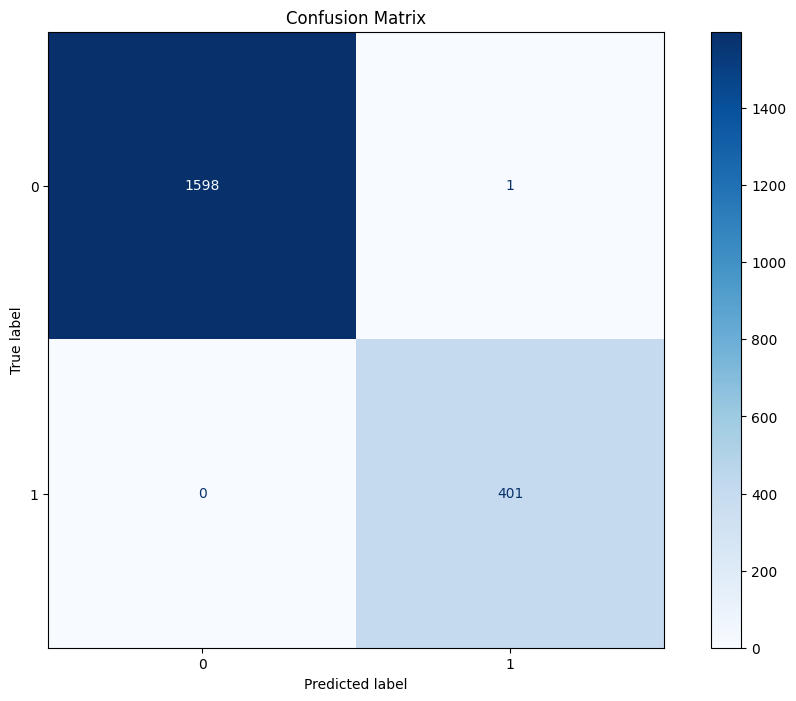

In [38]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## Глобальная интерпретация модели

Для интерпретации модели используется permutation importance. Этот метод измеряет, насколько ухудшается качество модели при случайной перестановке значений каждого признака, и позволяет определить, какие признаки действительно важны для предсказания.

В данной работе permutation importance считается по метрике `Recall` для положительного класса. Это особенно полезно, так как позволяет анализировать важность признаков именно с точки зрения способности модели находить хиты, а не просто общей точности классификации.


In [40]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring=make_scorer(recall_score, pos_label=1),
)

preproc = best_model.named_steps["preprocessor"]
feature_names_after = preproc.get_feature_names_out()

print("perm.importances_mean shape:", perm.importances_mean.shape)
print("feature_names_after len:", len(feature_names_after))

n_features_perm = perm.importances_mean.shape[0]
feature_names_after = np.array(feature_names_after)[:n_features_perm]

importance_df = pd.DataFrame(
    {
        "feature": feature_names_after,
        "importance": perm.importances_mean,
    }
).sort_values("importance", ascending=False)

importance_df.head(20)


perm.importances_mean shape: (17,)
feature_names_after len: 17712


,feature,importance
9,num__price,0.504988
11,num__discount,0.023192
0,num__appid,0.000000
1,num__score_rank,0.000000
2,num__positive,0.000000
5,num__average_forever,0.000000
6,num__average_2weeks,0.000000
3,num__negative,0.000000
4,num__userscore,0.000000
8,num__median_2weeks,0.000000


По результатам permutation importance наибольший вклад в качество модели вносит признак `price`, а также в меньшей степени `discount`. Остальные признаки в текущей конфигурации модели оказывают заметно более слабое влияние на полноту распознавания хитов.

Это означает, что при данном способе обучения и выбранной метрике модель в значительной степени ориентируется на ценовые характеристики игры. Такой результат можно интерпретировать как свидетельство того, что цена и скидки действительно связаны с вероятностью попадания игры в категорию успешных проектов, хотя для более глубокой интерпретации полезно дополнительно применять локальные методы объяснения.


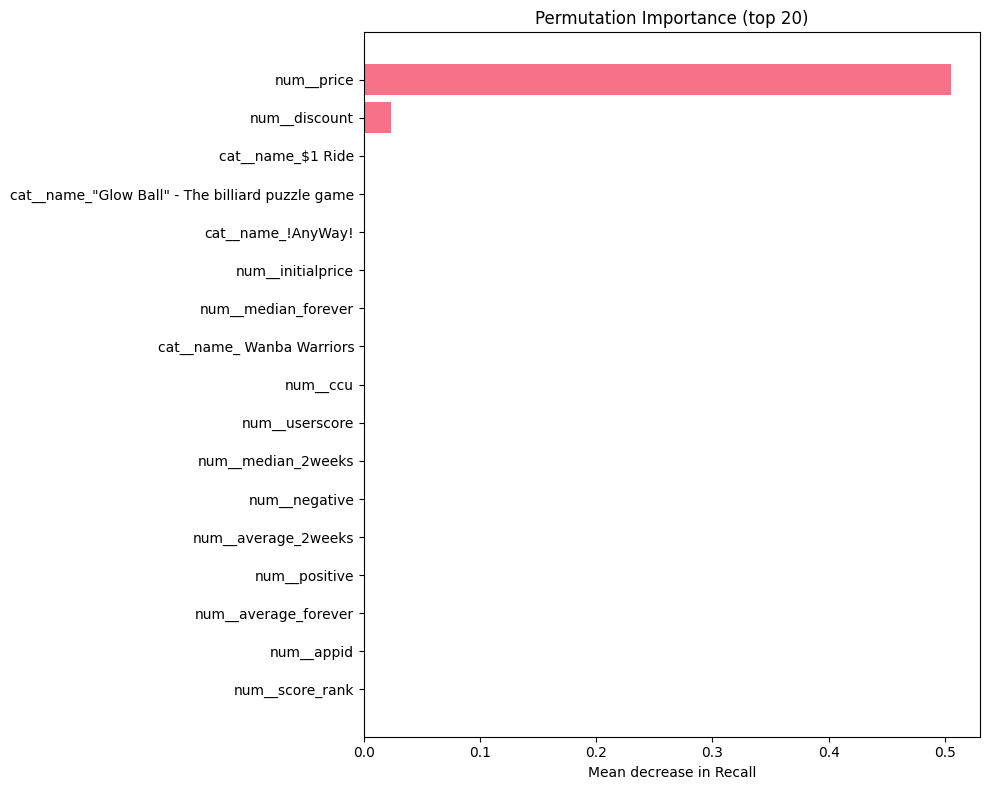

In [41]:
plt.figure(figsize=(10, 8))
top_imp = importance_df.head(20).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Permutation Importance (top 20)")
plt.xlabel("Mean decrease in Recall")
plt.tight_layout()
plt.show()


## Вывод

В ходе лабораторной работы была построена более сложная модель бинарной классификации на основе `RandomForestClassifier`, выполнен подбор гиперпараметров с помощью кросс-валидации и проведена оценка качества на тестовой выборке.

В качестве основной метрики использовался `Recall` по классу 1, что соответствует задаче поиска потенциально успешных игр. Итоговая модель показала работоспособный результат и позволила выявить наиболее значимые признаки, влияющие на распознавание хитов.

Дополнительный анализ важности признаков показал, что в текущей конфигурации наибольшее влияние на модель оказывают ценовые характеристики, прежде всего `price` и `discount`. Следовательно, модель можно считать не только рабочей, но и частично интерпретируемой с точки зрения предметной области.
